# 13 - 이중차분법 (Difference-in-Differences)

## 브라질 남부의 광고판 세 개

온라인 광고의 장점은 효과를 측정하기 쉽다는 것입니다. 누가 광고를 봤는지, 누가 클릭했는지, 누가 구매했는지 전부 데이터로 남기 때문이죠.

하지만 광고판이나 TV 광고처럼 "누가 봤는지 알 수 없는" 마케팅은 다릅니다. 광고판을 세우기 전후로 매출이 늘었다고 해도, 그게 정말 광고 때문인지 아니면 그냥 시기적으로 매출이 오르는 흐름이었는지 구분하기 어려워요.

**핵심 질문**: 광고판을 세우지 않았다면 어떻게 되었을까? (이 가상의 결과를 $Y_0$, counterfactual이라고 부릅니다)

이 질문에 답하는 방법 중 하나가 **이중차분법(DID, Difference-in-Differences)**입니다. 이민이 실업률에 미치는 영향, 총기법 개정이 범죄율에 미치는 영향, 마케팅 캠페인이 매출에 미치는 영향처럼, **개입 전/후 시점**이 있고 그 효과를 **전반적인 추세와 분리**해서 보고 싶을 때 널리 쓰이는 방법입니다.

### 실험 설정

브라질 남부 도시인 **포르투 알레그리(Porto Alegre, POA)**에 광고판 3개를 세우고, 예금(deposits)이 늘어나는지 확인하려 합니다.

문제는 "광고판이 없었다면 POA의 예금은 어떻게 됐을까"를 알 수 없다는 거예요. 그래서 광고판을 세우지 않은 **플로리아노폴리스(Florianópolis, FL)**를 대조군으로 사용합니다. 6월 한 달 동안 POA에 광고판을 세웠고, 데이터는 다음과 같습니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import style
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf


%matplotlib inline

style.use("fivethirtyeight")

In [3]:
data = pd.read_csv("data/billboard_impact.csv")
data.head()

,deposits,poa,jul
0,42,1,0
1,0,1,0
2,52,1,0
3,119,1,0
4,21,1,0


### 데이터 살펴보기

| 컬럼 | 의미 |
|---|---|
| `deposits` | 결과 변수. 광고판으로 늘리고 싶은 예금액 |
| `poa` | 1이면 Porto Alegre, 0이면 Florianópolis |
| `jul` | 1이면 개입 후 시점(7월), 0이면 개입 전 시점(5월) |

## DID 추정량은 어떻게 만들어지나

**표기법 정리**: 시간과 처치를 헷갈리지 않기 위해, $D$는 처치(treatment), $T$는 시간(time)을 나타냅니다. $Y_D(T)$는 "시점 $T$에서, 처치 상태가 $D$일 때의 결과"를 뜻해요.
> 여기서는 D=1 ⟺ POA, D=0 ⟺ Florianoˊpolis

만약 반사실(counterfactual)을 그냥 관찰할 수 있는 이상적인 세계라면, 처치 효과는 아주 간단하게 정의할 수 있습니다.

$$\hat{ATET} = E[Y_1(1) - Y_0(1)|D=1]$$

말로 풀면: "개입 후 시점에, **처치를 받았을 때의 결과**"에서 "개입 후 시점에, **처치를 받지 않았을 때의 결과(counterfactual)**"를 뺀 값이에요. 문제는 $Y_0(1)$은 반사실이라 **관찰할 수 없다**는 것 — 이게 인과추론의 근본적인 어려움입니다.

이걸 해결하려는 첫 번째 시도가 **전후 비교(Before-After)**입니다.

$$\hat{ATET} = E[Y(1)|D=1] - E[Y(0)|D=1]$$

POA에서 광고판을 세우기 전(5월)과 후(7월)의 평균 예금을 그냥 비교하는 거예요.

In [4]:
poa_before = data.query("poa==1 & jul==0")["deposits"].mean()

poa_after = data.query("poa==1 & jul==1")["deposits"].mean()

poa_after - poa_before

np.float64(41.04775)

이 값에 따르면 개입 후 예금이 R\$ 41.04 늘어난 것으로 보입니다. 그런데 이 숫자를 믿을 수 있을까요?

**왜 이 방법이 위험한지 표기법으로 뜯어보기**

개입 전 시점에는 아직 아무도 처치를 받지 않았습니다. 그러니 개입 전 POA에서 실제로 관찰한 값은, 자동으로 "처치를 안 받았을 때의 값"과 같습니다. 이건 그냥 정의상 참인 식이에요.

$$E[Y(0)|D=1] = E[Y_0(0)|D=1]$$

문제는 전후 비교법이 이 값을 **다른 시점**의 counterfactual인 $E[Y_0(1)|D=1]$ 대신 그냥 갖다 쓴다는 점입니다. 즉 암묵적으로 다음을 가정합니다.

$$E[Y_0(1)|D=1] \overset{?}{=} E[Y_0(0)|D=1]$$

풀어 말하면: **"처치가 없었다면, 시간이 지나도 결과는 그대로였을 것"** — 즉 트렌드가 전혀 없다는 가정입니다.

현실에서 예금은 자연스럽게 오르내리는 흐름이 있을 수 있어요.

- 예금이 원래 **증가 추세**라면 → 실제로는 $E[Y_0(1)|D=1] > E[Y_0(0)|D=1]$ (광고 없이도 후 시점이 더 클 것) → 가정이 틀림 → **효과를 과대평가**
- 예금이 원래 **감소 추세**라면 → $E[Y_0(1)|D=1] < E[Y_0(0)|D=1]$ → 가정이 틀림 → **효과를 과소평가**

**결론**: 전후 비교는 "처치 효과"와 "시간이 지나면서 생기는 자연스러운 변화"를 구분하지 못합니다.

### 두 번째 시도: 처치군 vs 대조군

그럼 대신 개입 **후** 시점에서, 처치받은 그룹과 처치받지 않은 그룹을 비교하면 어떨까요?

$$\hat{ATET} = E[Y(1)|D=1] - E[Y(1)|D=0]$$

개입 후(7월) POA의 예금을 같은 시점 Florianópolis의 예금과 비교하는 거예요.

In [5]:
fl_after = data.query("poa==0 & jul==1")["deposits"].mean()
poa_after - fl_after

np.float64(-119.10175000000001)

이번엔 R\$ 119.10만큼 예금이 **감소**한다는, 캠페인에 오히려 역효과가 있다는 결과가 나왔어요.

**이 방법은 왜 위험한가**

Florianópolis는 원래부터 처치를 받지 않으니, 관찰값이 곧 반사실값과 같습니다.

$$E[Y(1)|D=0] = E[Y_0(1)|D=0]$$

이 방법은 이 값을 POA의 counterfactual $E[Y_0(1)|D=1]$ 대신 쓰는 거예요. 즉 다음을 가정합니다.

$$E[Y_0(1)|D=0] \overset{?}{=} E[Y_0(1)|D=1]$$

말로 풀면: **"두 도시는 원래 수준(level)이 똑같다"**는 가정입니다.

- Florianópolis가 원래 POA보다 예금이 **훨씬 많은 도시**라면 → $E[Y_0(1)|D=0] > E[Y_0(1)|D=1]$ → 가정이 틀림
- 반대로 Florianópolis가 **더 적은 도시**라면 → $E[Y_0(1)|D=0] < E[Y_0(1)|D=1]$ → 역시 틀림

**결론**: 이 방법은 "처치 효과"와 "두 도시가 원래부터 갖고 있던 수준 차이"를 구분하지 못합니다.

### DID(Difference-in-Differences) 접근

정리하면 지금까지 두 방법의 문제는 이렇습니다.

| 방법 | 놓치는 것 | 필요했던 (틀린) 가정 |
|---|---|---|
| 전후 비교 | 자연스러운 시간 트렌드 | 트렌드가 없다 |
| 처치군 vs 대조군 | 두 그룹의 원래 수준 차이 | 수준이 똑같다 |

DID는 이 둘을 합쳐서, **"수준은 달라도 되지만, 변화하는 패턴(트렌드)은 같다"**고 가정합니다. 이게 훨씬 더 현실적인 가정이에요.

**표기법 확인**: $Y_D(T)$에서 아래첨자 $D$는 가정하는 처치 상태(0=안 받았다면), 괄호 안 $T$는 시간(0=5월, 1=7월)입니다. 그리고 `|D=1`은 실제 소속 그룹(POA)을 뜻해요.

수식으로 보면, 모르는 counterfactual $E[Y_0(1)|D=1]$ (POA가 광고 없이 7월을 맞았다면 얼마였을지)을 다음처럼 **쪼개서** 추정합니다.

$$E[Y_0(1)|D=1] = E[Y_0(0)|D=1] + \Big(E[Y_0(1)|D=0] - E[Y_0(0)|D=0]\Big)$$

각 항을 도시 이름으로 바로 바꿔보면 훨씬 명확해집니다.

| 기호 | 도시 이름으로 | 코드 변수 |
|---|---|---|
| $E[Y_0(1)\|D=1]$ (좌변, 모르는 값) | POA의 7월 counterfactual | — |
| $E[Y_0(0)\|D=1]$ | POA의 5월 실제값 | `poa_before` |
| $E[Y_0(1)\|D=0]$ | FL의 7월 실제값 | `fl_after` |
| $E[Y_0(0)\|D=0]$ | FL의 5월 실제값 | `fl_before` |

말로 풀면:

> **POA의 counterfactual (광고 없었을 때 7월 값)**
> = **POA가 실제로 갖고 있던 5월 값**
> + **Florianópolis가 5월→7월 사이 겪은 변화량**

즉 "모르는 값 = 내가 가진 값 + 대조군이 겪은 변화"로 대체하는 트릭입니다. 이걸 정당화하는 것이 바로 **평행 추세 가정(Parallel Trends Assumption)**이에요.

$$E[Y_0(1) - Y_0(0)|D=1] = E[Y_0(1) - Y_0(0)|D=0]$$

"POA가 광고를 안 세웠다면, POA와 Florianópolis는 똑같은 방향·속도로 변했을 것"이라는 뜻입니다. 두 도시의 *수준*이 달라도 괜찮아요 — 중요한 건 *변화하는 패턴*이 같다는 것뿐입니다.

이제 이 counterfactual을 처치 효과 정의 $E[Y_1(1)|D=1] - E[Y_0(1)|D=1]$에 대입하면:

$$\hat{ATET} = E[Y(1)|D=1] - \Big(E[Y(0)|D=1] + (E[Y(1)|D=0] - E[Y(0)|D=0])\Big)$$

항을 재배치하면 익숙한 DID 공식이 나옵니다.

$$\hat{ATET} = \Big(E[Y(1)|D=1] - E[Y(1)|D=0]\Big) - \Big(E[Y(0)|D=1] - E[Y(0)|D=0]\Big)$$

풀어 쓰면: **(POA의 전후 변화) − (Florianópolis의 전후 변화)**. "처치 전후 차이"와 "처치군-대조군 차이"를 **두 번 뺀다(difference-in-differences)**는 뜻에서 이 이름이 붙었습니다.

코드로 확인해볼게요.

In [7]:
fl_before = data.query("poa==0 & jul==0")["deposits"].mean()

diff_in_diff = (poa_after-poa_before)-(fl_after-fl_before)
diff_in_diff

np.float64(6.524557692307688)

DID 추정 결과, 예금은 고객당 R\$ 6.52만큼 늘어날 것으로 예상됩니다.

앞서 살펴본 두 방법(전후 비교: +41.04, 처치군 vs 대조군: -119.10)과 비교하면 훨씬 작고 온건한 값이죠. 왜 이 값이 더 믿을 만할까요? DID가 요구하는 가정("두 도시의 성장 패턴이 같다")이 앞의 두 방법이 요구한 가정("트렌드가 없다" 또는 "두 도시 수준이 같다")보다 훨씬 현실적이기 때문입니다. 두 도시가 같은 수준일 필요도, 트렌드가 0일 필요도 없어요.

이걸 그림으로 그리면 더 명확해집니다. 대조군(FL)의 성장 추세를 처치군(POA)의 5월 값 위에 그대로 얹어서, "광고가 없었다면 POA는 이 점선을 따라갔을 것"이라는 counterfactual을 그려볼 수 있어요.

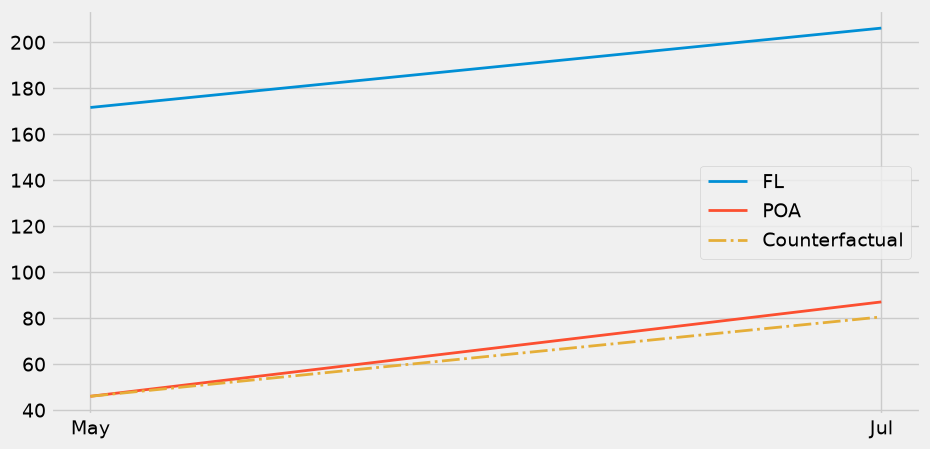

In [8]:
plt.figure(figsize=(10,5))
plt.plot(["May", "Jul"], [fl_before, fl_after], label="FL", lw=2)
plt.plot(["May", "Jul"], [poa_before, poa_after], label="POA", lw=2)

plt.plot(["May", "Jul"], [poa_before, poa_before+(fl_after-fl_before)],
         label="Counterfactual", lw=2, color="C2", ls="-.")

plt.legend();

빨간 선(POA 실제 값)과 노란 점선(POA counterfactual)의 간격이 바로 DID가 추정한 처치 효과입니다. 두 선이 거의 붙어있을 정도로 작은 효과라 눈으로는 잘 안 보이지만, 자세히 보면 아주 작은 차이가 있어요.

여기서 자연스러운 다음 질문: "이 숫자, 얼마나 믿을 수 있지? 표준오차(standard error)는 어디 있어?" 지금까지는 평균값만 손으로 계산했지만, **회귀분석(regression)**을 쓰면 같은 값을 얻으면서 표준오차까지 한 번에 구할 수 있습니다. 다음 선형 모델을 추정해봅니다.

$$Y_i = \beta_0 + \beta_1 POA_i + \beta_2 Jul_i + \beta_3 (POA_i \times Jul_i) + e_i$$

각 계수가 무엇을 의미하는지 표로 정리하면 이해가 쉬워요.

| 조건 (POA, Jul) | 얻는 값 | 의미 |
|---|---|---|
| (0, 0) | $\beta_0$ | 기준선: 5월 Florianópolis 예금 |
| (1, 0) | $\beta_0+\beta_1$ | 5월 POA 예금 → $\beta_1$ = 두 도시의 **원래 수준 차이** |
| (0, 1) | $\beta_0+\beta_2$ | 7월 Florianópolis 예금 → $\beta_2$ = 대조군의 **시간 트렌드** |
| (1, 1) | $\beta_0+\beta_1+\beta_2+\beta_3$ | 7월 POA 예금 → $\beta_3$ = **DID 추정량** |

즉 $\beta_3$는 "대조군에서 처치군으로 이동"하면서 **동시에** "개입 전에서 개입 후로 이동"할 때 추가로 붙는 증분이에요 — 이게 정확히 우리가 원하는 처치 효과입니다.

앞서 손으로 계산한 값(6.52)과 같은지 직접 확인해보세요.

In [9]:
smf.ols('deposits ~ poa*jul', data=data).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,171.6423,2.363,72.625,0.000,167.009,176.276
poa,-125.6263,4.484,-28.015,0.000,-134.418,-116.835
jul,34.5232,3.036,11.372,0.000,28.571,40.475
poa:jul,6.5246,5.729,1.139,0.255,-4.706,17.755


## 평행하지 않은 추세 (Non-Parallel Trends)

DID의 가장 큰 약점은 **평행 추세 가정이 항상 성립하지는 않는다**는 것입니다.

특히 처치 대상을 무작위로 고르지 않은 경우 문제가 될 수 있어요. 예를 들어 "매출이 유독 안 좋은 도시"를 골라서 광고판을 세웠다면 어떨까요? 원래 그 도시는 다른 도시들보다 성장세가 낮을 가능성이 있고, 이 경우:

- 광고판이 없었어도 POA의 성장은 다른 도시보다 낮게 관찰됐을 거예요
- 그러면 DID는 광고판의 실제 효과를 **과소평가**하게 됩니다

이런 문제가 있는지 확인하는 실용적인 방법은, **개입 전 여러 시점**의 데이터를 그려서 두 그룹의 추세가 실제로 평행했는지 점검하는 것입니다. 아래는 만약 POA가 원래 하락세, FL이 원래 급상승세였다면 어떻게 보일지를 보여주는 예시예요.

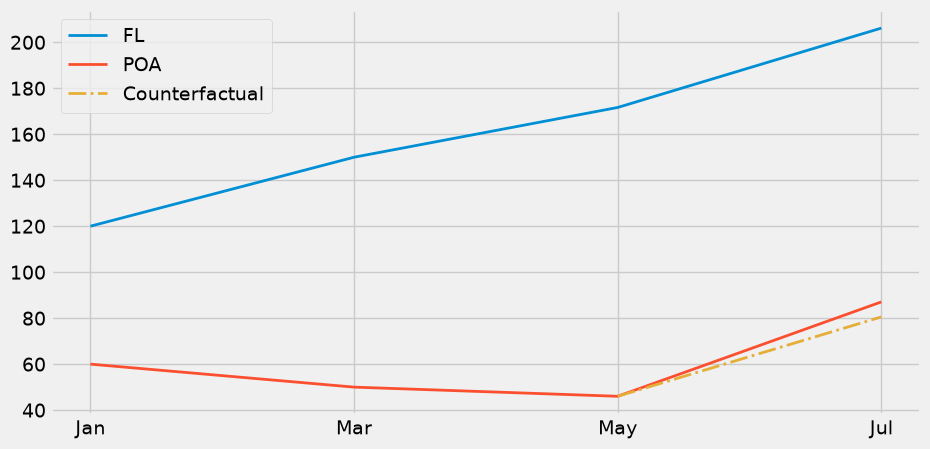

In [10]:
plt.figure(figsize=(10,5))
x = ["Jan", "Mar", "May", "Jul"]

plt.plot(x, [120, 150, fl_before,  fl_after], label="FL", lw=2)
plt.plot(x, [60, 50, poa_before, poa_after], label="POA", lw=2)

plt.plot(["May", "Jul"], [poa_before, poa_before+(fl_after-fl_before)], label="Counterfactual", lw=2, color="C2", ls="-.")

plt.legend();

1월, 3월 데이터까지 그려보니 두 도시가 원래부터 서로 다른 방향으로 움직이고 있었다는 게 드러납니다. 이런 경우 평행 추세 가정이 깨지고, DID 추정량은 신뢰할 수 없습니다.

이 문제를 해결하는 한 가지 방법이 Chapter 15에서 다루는 **Synthetic Control**입니다. 관심 있는 도시의 추세를 밀접하게 따라가는 "인위적인 대조군"을 여러 도시를 조합해서 만드는 방법이에요. 지금 단계에서 기억할 것은: **DID를 쓸 때는 항상 평행 추세 가정이 그럴듯한지 먼저 점검해야 한다**는 것입니다.

마지막으로 한 가지 더 — 만약 개인별 데이터가 아니라 **도시별 평균값만** 갖고 있다면(예: 두 도시의 전후 평균 예금만 있는 경우), DID로 점 추정치는 구할 수 있지만 **표준오차는 구할 수 없습니다**. 집계 과정에서 개인 간의 변동성 정보가 이미 사라졌기 때문이에요.

## 핵심 정리 (Key Ideas)

- DID는 학교·도시·주·국가 같은 **집단 단위의 개입 효과**를 추정할 때 널리 쓰이는 방법입니다.
- 아이디어는 단순합니다: **처치군의 전후 변화**에서 **대조군의 전후 변화**를 빼서, "순수한 처치 효과"만 남기는 것.
- 이게 가능하려면 **평행 추세 가정**(처치가 없었다면 두 그룹이 같은 방향으로 움직였을 것)이 필요합니다.
- 이 가정이 깨지면(예: 두 그룹이 원래부터 다른 추세를 갖고 있었다면) DID는 편향된 추정치를 줍니다.
- 집계된(aggregated) 데이터만 있으면 점 추정치는 얻어도 표준오차는 얻을 수 없습니다.

## 참고 자료

이 책은 Joshua Angrist, Alberto Abadie, Christopher Walters의 계량경제학 강의 자료(전미경제학회, AEA)를 많이 참고했습니다.

* [Cross-Section Econometrics](https://www.aeaweb.org/conference/cont-ed/2017-webcasts)
* [Mastering Mostly Harmless Econometrics](https://www.aeaweb.org/conference/cont-ed/2020-webcasts)

Angrist의 저서들도 훌륭한 참고자료입니다.

* [Mostly Harmless Econometrics](https://www.mostlyharmlesseconometrics.com/)
* [Mastering 'Metrics](https://www.masteringmetrics.com/)

Miguel Hernan과 Jamie Robins의 책도 큰 도움이 되었습니다.

* [Causal Inference Book](https://www.hsph.harvard.edu/miguel-hernan/causal-inference-book/)

Scott Cunningham의 Mixtape 자료에도 감사를 전합니다.

* [Causal Inference: The Mixtape](https://www.scunning.com/mixtape.html)

## 기여하기 (Contribute)

Causal Inference for the Brave and True는 인과추론·통계학에 대한 오픈소스 자료입니다. 금전적으로 지원하고 싶으시다면 [Patreon](https://www.patreon.com/causal_inference_for_the_brave_and_true)을 방문해주세요. 오타 수정이나 피드백은 [Github 이슈 페이지](https://github.com/CausalInferenceLab/Causal-Inference-with-Python/issues)에서 남길 수 있습니다. 도움이 되셨다면 [한국어 번역 자료](https://github.com/CausalInferenceLab/Causal-Inference-with-Python/stargazers)와 [원서 저장소](https://github.com/matheusfacure/python-causality-handbook/stargazers)에 star를 부탁드립니다!